## SMS Spam Detection using Naive Bayes

### Introduction

This project implements a machine learning model to classify SMS messages as **spam** or **ham (not spam)**.

The model uses a supervised learning approach with the **Multinomial Naive Bayes** algorithm. The main steps include loading the dataset, exploring the data, preprocessing the text, converting text into numerical features, training the model, and evaluating its performance.


### Loading the Dataset

We load the SMS dataset using `pandas`. The file does not contain a header row, so the column names are manually defined as `label` and `message`.

The `label` column indicates whether the SMS is `spam` or `ham`, while the `message` column contains the text of the SMS.


In [29]:
import pandas as pd

df = pd.read_csv("/content/sms-spam-dataset.txt", sep="\t", names=["label", "message"])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Dataset Shape

We check the shape of the dataset to identify the number of messages and columns available.


In [30]:
df.shape


(5572, 2)

### Class Distribution

We analyze how many messages belong to each class. This helps us understand whether the dataset is balanced or imbalanced.


In [31]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


### Missing Values

Before training a model, it is important to check whether the dataset contains missing values that could affect preprocessing or model training.


In [32]:
df.isnull().sum()

,0
label,0
message,0


### Class Distribution in Percentage

The class distribution is also calculated as a percentage to better understand the proportion of spam and ham messages in the dataset.


In [33]:
df["label"].value_counts(normalize=True) * 100

,proportion
label,
ham,86.593683
spam,13.406317


### Example Message

We inspect one SMS message from the dataset to understand the type of text that will be processed by the model.


In [34]:
df["message"][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

### Train-Test Split

The dataset is split into training and testing subsets. The model is trained on 80% of the data and evaluated on the remaining 20%.

This approach allows us to evaluate how well the model generalizes to unseen data.


In [35]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4457,)
(1115,)


### Text Preprocessing Function

Machine learning models cannot directly understand raw text. Therefore, the text is normalized by converting it to lowercase and removing punctuation.

This reduces noise and makes the text more consistent before vectorization.


In [36]:
import string

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

### Applying Text Preprocessing

The cleaning function is applied separately to the training and testing datasets.

This keeps the preprocessing pipeline consistent while preserving the separation between train and test data.


In [37]:
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

### Comparing Original and Cleaned Text

Here we compare an original message with its cleaned version to verify that the preprocessing step worked correctly.


In [38]:
print(X_train.iloc[0])
print(X_train_clean.iloc[0])

Reply to win £100 weekly! Where will the 2006 FIFA World Cup be held? Send STOP to 87239 to end service
reply to win £100 weekly where will the 2006 fifa world cup be held send stop to 87239 to end service


### Feature Extraction with CountVectorizer

The cleaned text is converted into numerical features using `CountVectorizer`.

This technique follows the **Bag-of-Words** approach, where each message is represented as a vector based on word frequencies.

The vectorizer is fitted only on the training data and then applied to the test data. This helps avoid data leakage.


In [39]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

vectorizer = CountVectorizer()

X_train_vect = vectorizer.fit_transform(X_train_clean)
X_test_vect = vectorizer.transform(X_test_clean)

df_shapes = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Number of messages": [4457, 1115],
    "Number of features": [8395, 8395]
})

df_shapes


,Conjunto,Número de mensagens,Número de features
0,Treino,4457,8395
1,Teste,1115,8395


### Vectorized Data Shape

After vectorization, each message is represented as a numerical vector. The number of columns corresponds to the size of the vocabulary learned from the training data.


In [40]:
print(X_train_vect.shape)
print(X_test_vect.shape)

(4457, 8395)
(1115, 8395)


### Vocabulary Preview

This step displays a small sample of the vocabulary generated by the vectorizer. Each term in the vocabulary becomes a feature used by the model.


In [41]:
print(vectorizer.get_feature_names_out()[:50])

['008704050406' '0089my' '0121' '01223585236' '01223585334' '020603'
 '0207' '02070836089' '02072069400' '02073162414' '02085076972' '020903'
 '021' '050703' '0578' '06' '061104' '07008009200' '07046744435'
 '07090298926' '07099833605' '071104' '07123456789' '0721072'
 '07732584351' '07734396839' '07742676969' '07753741225' '0776xxxxxxx'
 '07786200117' '077xxx' '07801543489' '07808' '07808247860' '07808726822'
 '07815296484' '07821230901' '0794674629107880867867' '0796xxxxxx'
 '07973788240' '07xxxxxxxxx' '0800' '08000407165' '08000776320'
 '08000839402' '08000930705' '08000938767' '08001950382' '08002888812'
 '08002986030']


### Model Training

We train a **Multinomial Naive Bayes** classifier using the vectorized training data.

This algorithm is well suited for text classification problems because it works effectively with discrete features such as word counts.


In [42]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vect, y_train)

MultinomialNB()

### Accuracy Evaluation

The trained model is used to predict the labels of the test data.

Accuracy measures the proportion of correct predictions among all test samples.


In [43]:
y_pred = model.predict(X_test_vect)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred) * 100
print(accuracy)

98.7443946188341


### Confusion Matrix

The confusion matrix shows how many messages were correctly and incorrectly classified for each class.

This is especially useful for identifying false positives and false negatives.


In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[966   0]
 [ 14 135]]


### Predicting a New Message

We now test the trained model with a new SMS message that was manually created.


In [45]:
nova_msg = ["Congratulations! You won a free ticket"]


### Preprocessing the New Message

The new message must go through the same preprocessing steps used during training.


In [46]:
nova_msg_clean = [clean_text(msg) for msg in nova_msg]
nova_msg_clean

['congratulations you won a free ticket']

### Vectorizing the New Message

The cleaned message is transformed using the same vectorizer fitted on the training data.


In [47]:
nova_msg_vect = vectorizer.transform(nova_msg_clean)
print(nova_msg_vect.shape)

(1, 8395)


### Making a Prediction

The trained model predicts whether the new message is spam or ham.


In [48]:
pred = model.predict(nova_msg_vect)
pred

array(['spam'], dtype='<U4')

### Displaying the Prediction

The prediction result is displayed in a more readable format.


In [49]:
if pred[0] == "spam":
    print("Message classified as SPAM")
else:
    print("Message classified as HAM")

Mensagem classificada como SPAM


### Testing Multiple New Messages

We test the model with different types of messages, including clear spam examples, normal messages, ambiguous messages, and messages containing unfamiliar words.

This helps demonstrate how the model behaves with new inputs.


In [50]:
test_messages = [
    "Congratulations! You won a free ticket",
    "Hey, are we meeting today?",
    "URGENT! You have won £1000 cash prize",
    "Can you call me when you get home?",
    "Free entry! Text WIN to 80086 now",
    "Don't forget the meeting tomorrow at 10",
    "quantum flux nebula signal",
    "crypto unicorn token blockchain magic",
    "galaxy hyperdrive interstellar message",
    "win free crypto tokens now",
    "urgent meeting about blockchain project",
    "call me later about quantum research",
    "free meeting tomorrow at office",
    "urgent call me when you arrive",
    "win a meeting with your manager",
    "free prize click now",
    "win money now urgent",
    "exclusive offer claim your reward",
    "see you at dinner tonight",
    "can you send me the file",
    "meeting starts at 10 tomorrow"

]

test_messages_clean = [clean_text(msg) for msg in test_messages]
test_messages_vect = vectorizer.transform(test_messages_clean)

predictions = model.predict(test_messages_vect)

for msg, pred in zip(test_messages, predictions):
    print(f"Message: {msg}")
    print(f"Prediction: {pred}")
    print("-" * 50)

Mensagem: Congratulations! You won a free ticket
Classificação: spam
--------------------------------------------------
Mensagem: Hey, are we meeting today?
Classificação: ham
--------------------------------------------------
Mensagem: URGENT! You have won £1000 cash prize
Classificação: spam
--------------------------------------------------
Mensagem: Can you call me when you get home?
Classificação: ham
--------------------------------------------------
Mensagem: Free entry! Text WIN to 80086 now
Classificação: spam
--------------------------------------------------
Mensagem: Don't forget the meeting tomorrow at 10
Classificação: ham
--------------------------------------------------
Mensagem: quantum flux nebula signal
Classificação: ham
--------------------------------------------------
Mensagem: crypto unicorn token blockchain magic
Classificação: ham
--------------------------------------------------
Mensagem: galaxy hyperdrive interstellar message
Classificação: ham
-----------

### Visualizing Class Distribution

This bar chart shows the distribution of spam and ham messages in the dataset.


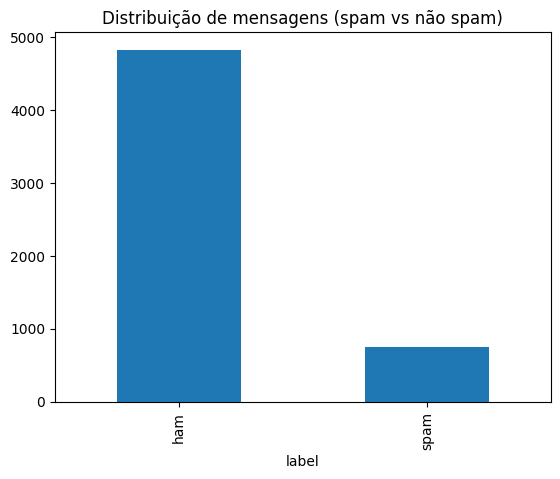

In [51]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Message Distribution (spam vs ham)")
plt.show()

### Visualizing the Confusion Matrix

A heatmap is used to make the confusion matrix easier to interpret visually.


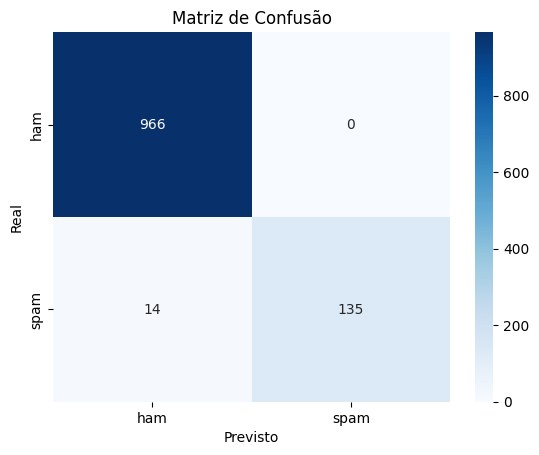

In [52]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"],
            yticklabels=["ham", "spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Most Frequent Words

This chart displays the most frequent words in the training data after vectorization.

It gives an overview of the terms that appear most often in the dataset.


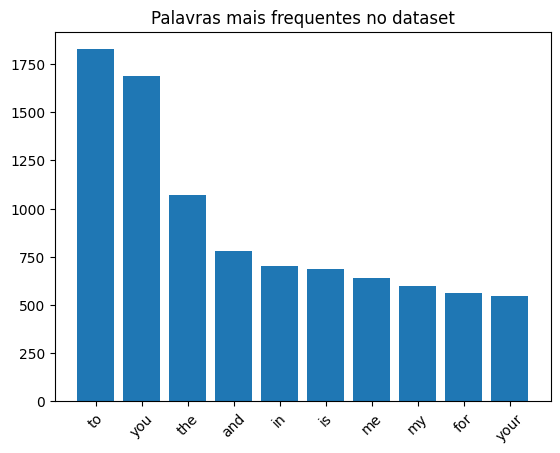

In [53]:
import numpy as np

sum_words = X_train_vect.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:10]

words = [w[0] for w in words_freq]
counts = [w[1] for w in words_freq]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Most Frequent Words in the Dataset")
plt.show()

### Message Length Distribution

We analyze the distribution of message lengths to better understand the structure of the SMS messages.


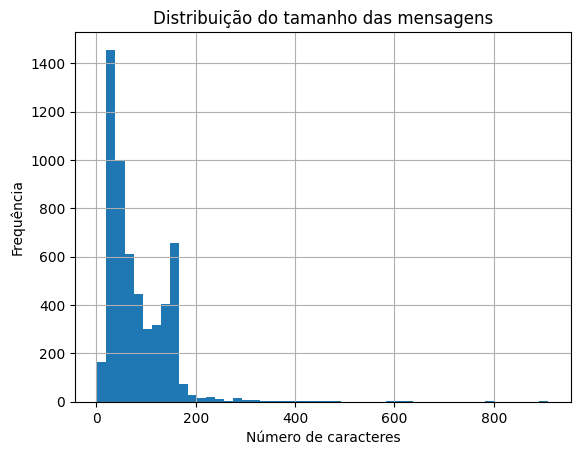

In [54]:
df["length"] = df["message"].apply(len)

df["length"].hist(bins=50)
plt.title("Message Length Distribution")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

### Most Relevant Words for Spam

This step inspects the words with the highest probability for the spam class according to the trained Naive Bayes model.


In [55]:
import numpy as np


feature_names = vectorizer.get_feature_names_out()
spam_class_index = list(model.classes_).index('spam') # index of the spam class
spam_log_prob = model.feature_log_prob_[spam_class_index]

# Mostrar as 10 palavras mais comuns em Spam
top_10_spam_indices = np.argsort(spam_log_prob)[-10:]
print("Top 10 spam-related words:", [feature_names[i] for i in top_10_spam_indices])


Top 10 palavras de Spam: ['on', 'now', 'the', 'or', 'for', 'free', 'your', 'you', 'call', 'to']


### Vocabulary Size

Finally, we check the total number of unique words learned by the vectorizer.


In [56]:
print("Total number of unique words (V):", len(feature_names))


Total de palavras únicas (V): 8395
